# 서울 공공자전거 따릉이 이용량 시계열 분석

## 분석 주제
2025년 서울 공공자전거 따릉이의 일별 대여건수를 분석하여
시간에 따른 추세, 월별·요일별 패턴, 급격한 이용량 변화 구간을 확인한다.

## 분석 질문

1. 2025년 따릉이 이용량은 시간에 따라 어떤 추세를 보였는가?
2. 따릉이 이용량은 월별로 어떤 차이를 보이는가?
3. 따릉이 이용량은 요일에 따라 어떤 차이를 보이는가?
4. 이용량이 급격하게 증가하거나 감소한 시점은 언제인가?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

## 1. 데이터 설명

- 데이터명: 서울특별시 공공자전거 일별 대여건수
- 분석 기간: 2025-01-01 ~ 2025-12-31
- 데이터 수: 365개
- 주요 컬럼
  - `대여일자`: 날짜
  - `대여건수`: 해당 날짜의 따릉이 총 대여건수
- 데이터 출처: 서울 열린데이터광장

2025년 상반기(1월~6월)와 하반기(7월~12월) 데이터를 하나의 DataFrame으로 병합하여 분석한다.

In [2]:
first_path = glob.glob('/content/*25.1-6.csv')[0]
second_path = glob.glob('/content/*25.7-12.csv')[0]

df_first = pd.read_csv(first_path, encoding='cp949')
df_second = pd.read_csv(second_path, encoding='cp949')

df = pd.concat([df_first, df_second], ignore_index=True)

df['대여일자'] = pd.to_datetime(df['대여일자'])
df = df.sort_values('대여일자').reset_index(drop=True)

display(df.head())
display(df.tail())

print(df.shape)

,대여일자,대여건수
0,2025-01-01,48645
1,2025-01-02,77718
2,2025-01-03,77053
3,2025-01-04,56597
4,2025-01-05,19712


,대여일자,대여건수
360,2025-12-27,42381
361,2025-12-28,40774
362,2025-12-29,66652
363,2025-12-30,71026
364,2025-12-31,55570


(365, 2)


## 2. 데이터 정제 및 품질 확인

분석에 앞서 데이터의 기간, 자료형, 결측치, 중복 데이터,
누락 날짜 여부를 확인하였다.

확인 결과 원본 데이터에는 결측치, 중복 날짜, 누락 날짜가 존재하지 않아
별도의 결측치 보간이나 중복 제거는 수행하지 않았다.

In [3]:
df.info()

print("시작일:", df['대여일자'].min())
print("종료일:", df['대여일자'].max())
print("데이터 개수:", len(df))

display(df.isnull().sum())

print("전체 중복:", df.duplicated().sum())
print("날짜 중복:", df['대여일자'].duplicated().sum())

display(df['대여건수'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   대여일자    365 non-null    datetime64[ns]
 1   대여건수    365 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.8 KB
시작일: 2025-01-01 00:00:00
종료일: 2025-12-31 00:00:00
데이터 개수: 365


,0
대여일자,0
대여건수,0


전체 중복: 0
날짜 중복: 0


,대여건수
count,365.000000
mean,102392.032877
std,42357.648004
min,10493.000000
25%,68177.000000
50%,108852.000000
75%,138009.000000
max,176011.000000


In [4]:
full_dates = pd.date_range(
    start=df['대여일자'].min(),
    end=df['대여일자'].max(),
    freq='D'
)

missing_dates = full_dates.difference(df['대여일자'])

print("누락 날짜 수:", len(missing_dates))
print(missing_dates)

누락 날짜 수: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


## 3. 시계열 분석 방법

분석 질문에 답하기 위해 다음 시계열 분석 기법을 적용하였다.

1. **7일 이동평균**
   - 일별 변동을 완화하고 단기적인 추세를 확인하기 위해 사용하였다.

2. **30일 이동평균**
   - 보다 장기적인 이용량 변화 흐름을 확인하기 위해 사용하였다.

3. **월별·요일별 집계**
   - 월과 요일에 따라 반복되는 패턴이 존재하는지 확인하였다.

4. **전일 대비 변화율**
   - 특정 날짜에 발생한 급격한 증가 및 감소 구간을 찾기 위해 사용하였다.

In [5]:
# 월
df['월'] = df['대여일자'].dt.month

# 요일 번호: 월요일=0, 일요일=6
df['요일번호'] = df['대여일자'].dt.dayofweek

# 7일 이동평균
df['7일_이동평균'] = df['대여건수'].rolling(window=7).mean()

# 30일 이동평균
df['30일_이동평균'] = df['대여건수'].rolling(window=30).mean()

# 전일 대비 변화율(%)
df['변화율'] = df['대여건수'].pct_change() * 100

df.head(10)

,대여일자,대여건수,월,요일번호,7일_이동평균,30일_이동평균,변화율
0,2025-01-01,48645,1,2,NaN,NaN,NaN
1,2025-01-02,77718,1,3,NaN,NaN,59.765649
2,2025-01-03,77053,1,4,NaN,NaN,-0.855658
3,2025-01-04,56597,1,5,NaN,NaN,-26.547960
4,2025-01-05,19712,1,6,NaN,NaN,-65.171299
5,2025-01-06,62525,1,0,NaN,NaN,217.192573
6,2025-01-07,68411,1,1,58665.857143,NaN,9.413834
7,2025-01-08,66720,1,2,61248.000000,NaN,-2.471825
8,2025-01-09,47971,1,3,56998.428571,NaN,-28.101019
9,2025-01-10,54569,1,4,53786.428571,NaN,13.754143


## 4. 분석 결과 및 시각화

### 4-1. 일별 대여건수와 이동평균

일별 대여건수는 하루 단위의 변동이 크기 때문에
7일 이동평균과 30일 이동평균을 사용하여
단기 및 장기적인 이용량 추세를 확인하였다.

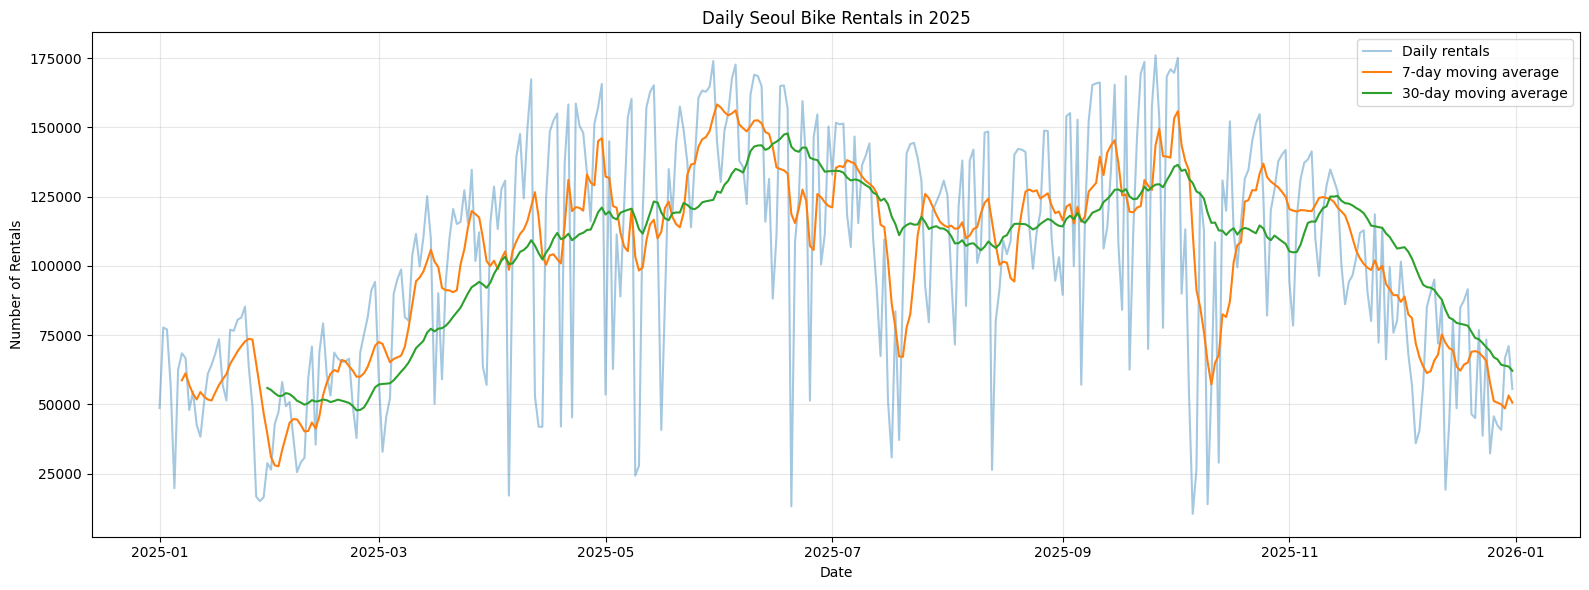

In [6]:
import os

os.makedirs('images', exist_ok=True)

plt.figure(figsize=(16, 6))

plt.plot(
    df['대여일자'],
    df['대여건수'],
    label='Daily rentals',
    alpha=0.4
)

plt.plot(
    df['대여일자'],
    df['7일_이동평균'],
    label='7-day moving average'
)

plt.plot(
    df['대여일자'],
    df['30일_이동평균'],
    label='30-day moving average'
)

plt.title('Daily Seoul Bike Rentals in 2025')
plt.xlabel('Date')
plt.ylabel('Number of Rentals')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('images/01_daily_trend.png', dpi=300)
plt.show()

**관찰**

겨울철에는 대여량이 비교적 낮았으며 봄부터 증가하는 흐름이 나타났다.
6월까지 증가한 뒤 7~8월에는 다소 감소하고,
9월에 다시 증가한 후 연말로 갈수록 감소하는 패턴을 확인할 수 있다.

7일 이동평균은 단기적인 변화를,
30일 이동평균은 계절에 따른 보다 장기적인 흐름을 보여준다.

### 4-2. 월별 평균 대여건수

월별 평균 대여건수를 비교하여
따릉이 이용량의 계절적 차이를 확인하였다.

In [7]:
monthly_avg = df.groupby('월')['대여건수'].mean()

monthly_avg

,대여건수
월,
1,54978.580645
2,58197.857143
3,92804.870968
4,121026.666667
5,124496.387097
6,134143.833333
7,114071.064516
8,114814.935484
9,133077.533333


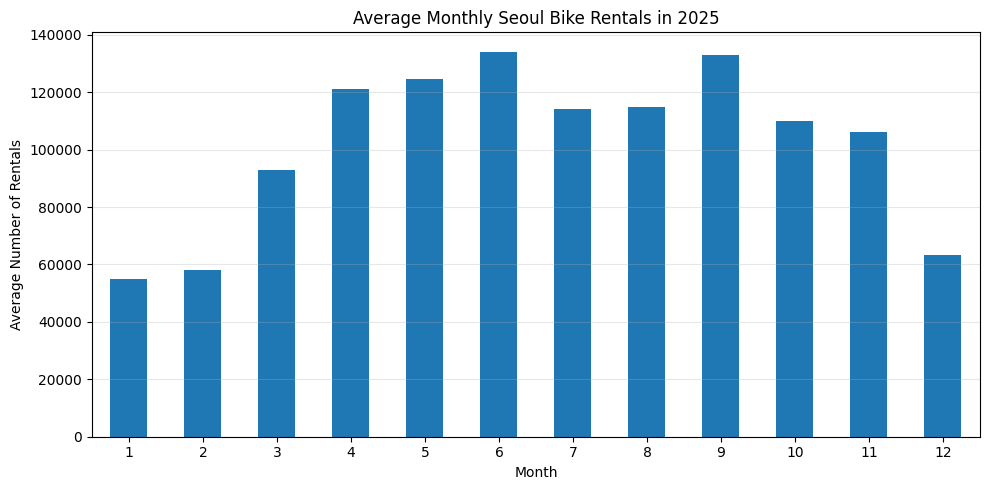

In [8]:
plt.figure(figsize=(10, 5))

monthly_avg.plot(kind='bar')

plt.title('Average Monthly Seoul Bike Rentals in 2025')
plt.xlabel('Month')
plt.ylabel('Average Number of Rentals')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/02_monthly_average.png', dpi=300)
plt.show()

**관찰**

월별 평균 대여건수는 1월 약 5.5만 건에서 증가하여
6월 약 13.4만 건으로 가장 높은 수준을 기록하였다.

7~8월에는 약 11.4만 건으로 감소했으나
9월에 약 13.3만 건으로 다시 증가하였다.
이후 겨울로 갈수록 대여건수가 감소하였다.

따라서 따릉이 이용량에는 월별·계절별 차이가 존재하는 것으로 보인다.

### 4-3. 요일별 평균 대여건수

요일에 따라 이용량이 어떻게 달라지는지 확인하기 위해
요일별 평균 대여건수를 비교하였다.

In [9]:
weekday_avg = (
    df.groupby('요일번호')['대여건수']
    .mean()
    .reindex(range(7))
)

weekday_avg

,대여건수
요일번호,
0,106771.461538
1,110918.134615
2,110986.584906
3,114743.903846
4,104896.807692
5,82936.519231
6,85325.538462


In [10]:
# 0 = Monday
# 1 = Tuesday
# 2 = Wednesday
# 3 = Thursday
# 4 = Friday
# 5 = Saturday
# 6 = Sunday

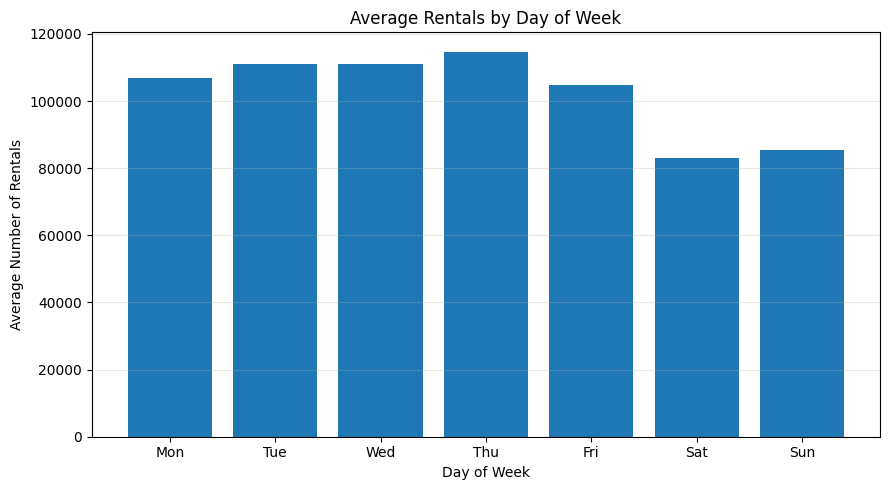

In [11]:
weekday_labels = [
    'Mon', 'Tue', 'Wed', 'Thu',
    'Fri', 'Sat', 'Sun'
]

plt.figure(figsize=(9, 5))

plt.bar(
    weekday_labels,
    weekday_avg.values
)

plt.title('Average Rentals by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Number of Rentals')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/03_weekday_average.png', dpi=300)
plt.show()

**관찰**

목요일의 평균 대여건수가 약 11.5만 건으로 가장 높았으며,
토요일은 약 8.3만 건으로 가장 낮았다.

전체적으로 토요일과 일요일보다 평일의 평균 이용량이 높게 나타났다.

**해석**

주말보다 평일 이용량이 높은 결과는 따릉이가 여가 목적뿐 아니라
출퇴근이나 통학 등 일상적인 이동수단으로 활용되고 있을 가능성을 보여준다.

다만 현재 데이터에는 이용 목적이 포함되어 있지 않으므로
출퇴근이나 통학이 직접적인 원인이라고 단정할 수는 없다.

### 4-4. 급격한 이용량 변화

전일 대비 변화율을 계산하여 대여건수가 급격하게 증가하거나
감소한 날짜를 확인하였다.

변화 폭이 큰 데이터는 결측치나 중복 등 데이터 오류로 확인되지 않았으므로
제거하지 않고 실제 시계열 변화로 판단하여 분석에 포함하였다.

In [12]:
largest_increases = (
    df.nlargest(5, '변화율')
    [['대여일자', '대여건수', '변화율']]
)

largest_decreases = (
    df.nsmallest(5, '변화율')
    [['대여일자', '대여건수', '변화율']]
)

print("=== 전일 대비 대여건수 증가율 TOP 5 ===")
display(largest_increases)

print("=== 전일 대비 대여건수 감소율 TOP 5 ===")
display(largest_decreases)

=== 전일 대비 대여건수 증가율 TOP 5 ===


,대여일자,대여건수,변화율
171,2025-06-21,108852,725.950376
95,2025-04-06,104882,515.035478
280,2025-10-08,126692,374.982192
286,2025-10-14,130815,351.990187
130,2025-05-11,118904,327.343301


=== 전일 대비 대여건수 감소율 TOP 5 ===


,대여일자,대여건수,변화율
170,2025-06-20,13179,-91.593417
282,2025-10-10,13940,-87.667209
94,2025-04-05,17053,-86.960046
128,2025-05-09,24264,-84.859509
224,2025-08-13,26358,-82.245962


In [13]:
# 급감 TOP 5 날짜
drop_dates = largest_decreases['대여일자']

event_rows = []

for date in drop_dates:
    idx = df.index[df['대여일자'] == date][0]

    start = max(0, idx - 1)
    end = min(len(df), idx + 2)

    temp = df.loc[
        start:end-1,
        ['대여일자', '대여건수', '변화율']
    ].copy()

    temp['급감기준일'] = date

    event_rows.append(temp)

event_windows = pd.concat(event_rows)

display(event_windows)

,대여일자,대여건수,변화율,급감기준일
169,2025-06-19,156770,-5.059228,2025-06-20
170,2025-06-20,13179,-91.593417,2025-06-20
171,2025-06-21,108852,725.950376,2025-06-20
281,2025-10-09,113032,-10.782054,2025-10-10
282,2025-10-10,13940,-87.667209,2025-10-10
283,2025-10-11,55778,300.129125,2025-10-10
93,2025-04-04,130775,2.356689,2025-04-05
94,2025-04-05,17053,-86.960046,2025-04-05
95,2025-04-06,104882,515.035478,2025-04-05
127,2025-05-08,160259,4.300655,2025-05-09


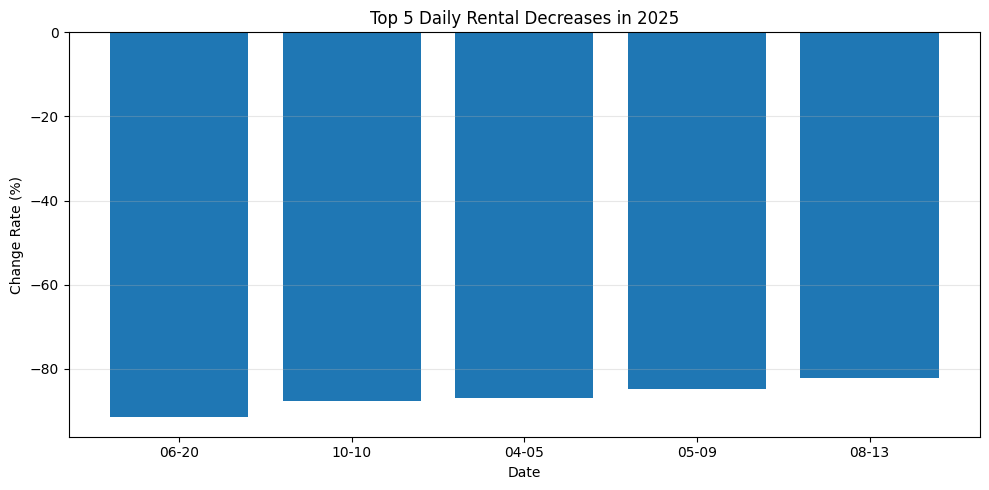

In [14]:
plt.figure(figsize=(10, 5))

plt.bar(
    largest_decreases['대여일자'].dt.strftime('%m-%d'),
    largest_decreases['변화율']
)

plt.title('Top 5 Daily Rental Decreases in 2025')
plt.xlabel('Date')
plt.ylabel('Change Rate (%)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/04_largest_decreases.png', dpi=300)
plt.show()

**관찰**

2025년에는 특정 날짜에 전일 대비 대여건수가 80~90% 이상
급감하는 사례가 나타났다.

대표적으로 6월 20일에는 전일 대비 약 91.6% 감소하였으며,
다음 날 이용량이 크게 회복하는 모습을 보였다.

**해석**

이러한 급격한 변화는 장기적인 이용 수요 변화라기보다
강수, 기온 등 특정 날짜의 외부 환경에 영향을 받았을 가능성이 있다.

다만 현재 분석 데이터에는 날씨 정보가 포함되어 있지 않으므로,
날씨와 이용량 사이의 직접적인 인과관계는 확인할 수 없다.

## 5. 주요 인사이트

### 인사이트 1. 따릉이 이용량에는 뚜렷한 계절적 패턴이 나타났다.
- 1월 평균 대여건수는 약 5.5만 건이었으며, 6월에는 약 13.4만 건으로 증가하였다.
- 7~8월에는 다소 감소한 뒤 9월에 약 13.3만 건으로 다시 증가하였다.
- 겨울보다 봄·초여름·초가을의 이용량이 높은 패턴을 확인할 수 있었다.

### 인사이트 2. 주말보다 평일 이용량이 높았다.
- 목요일 평균 대여건수는 약 11.5만 건으로 가장 높았고,
  토요일은 약 8.3만 건으로 가장 낮았다.
- 전체적으로 평일 이용량이 주말보다 높게 나타났다.
- 출퇴근이나 통학과 같은 일상 이동 수요가 영향을 주었을 가능성이 있으나,
  현재 데이터만으로 이용 목적을 직접 확인할 수는 없다.

### 인사이트 3. 특정 날짜에는 일시적인 급감 현상이 나타났다.
- 6월 20일에는 전일 대비 약 91.6% 감소하였다.
- 10월 10일, 4월 5일, 5월 9일, 8월 13일에도 80% 이상의 급감이 나타났다.
- 이러한 변화는 날씨 등 외부 환경의 영향을 받았을 가능성이 있다.

## 6. 결론 및 한계점

2025년 서울 따릉이 이용량을 분석한 결과,
월별·요일별로 반복적인 이용 패턴이 존재하며
특정 날짜에는 매우 큰 단기 변동도 발생하는 것을 확인하였다.

이동평균을 통해 겨울에는 이용량이 낮고 봄부터 증가한 뒤
연말로 갈수록 다시 감소하는 장기적인 흐름을 확인하였다.
또한 주말보다 평일의 평균 이용량이 높게 나타났다.

### 한계점

- 분석 기간이 2025년 1년으로 제한되어 있어 연도별 장기 추세를 확인하기 어렵다.
- 데이터에 기온, 강수량 등 기상 정보가 포함되어 있지 않다.
- 이용 목적이나 이용자의 특성을 확인할 수 없어 평일·주말 차이의 원인을 직접적으로 설명할 수 없다.
- 특정 날짜의 급격한 변화와 외부 요인 사이의 인과관계를 현재 데이터만으로 판단하기 어렵다.

향후 기상 데이터, 공휴일 정보 등을 결합하면
따릉이 이용량 변화의 원인을 보다 구체적으로 분석할 수 있다.

## 7. AI 사용 로그

### 사용 작업
- 분석 질문 구체화
- 데이터 전처리 및 시계열 분석 코드 작성 보조
- 이동평균, 변화율, 월별·요일별 집계 방법 검토
- 시각화 코드 작성 및 결과 해석 보조
- 분석 결과 문장 정리

### 사용 이유
- 분석 과정에서 적절한 시계열 분석 방법을 탐색하고 코드 작성 시간을 줄이기 위해 AI를 활용하였다.
- 분석 결과에 대해 다양한 해석 가능성을 검토하기 위해 활용하였다.

### 검증 방법
- AI가 제안한 코드를 Google Colab에서 직접 실행하여 결과를 확인하였다.
- 데이터의 결측치, 중복, 기간 및 통계값을 직접 확인하였다.
- 그래프와 실제 집계 수치를 비교하여 해석이 데이터와 일치하는지 확인하였다.
- 데이터만으로 확인할 수 없는 원인은 사실로 단정하지 않고 가설로 구분하였다.